# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shweta1805/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can historical search-performance signals help identify content pages that are likely to experience a meaningful decline in future Google Search impressions?

### Decision supported

The analysis supports the decision of which content pages should be prioritized for review or refresh.

The goal is not to claim that a refresh will cause a ranking improvement. Instead, the system provides a repeatable, evidence-based prioritization of pages for human review.

## 2. Data

### Dataset and data sources

This study uses the public-safe FlyRank ML Internship warehouse release hosted on Hugging Face.

**Primary table**
- `fact_content_daily_performance` — daily search and engagement performance for anonymized content.

**Supporting tables**
- `dim_clients` — anonymized client-level reference information.
- `dim_content` — anonymized content-level reference information.

### Observation and modeling window

The warehouse contains data from January 2025 through June 2026. The modeling window runs from March 2025 through May 2026.

March 2025 is used as the earliest modeling month because the earlier months contain substantially fewer content items. June 2026 is retained as the future outcome month for May 2026 because it is the latest available month in the warehouse.

The daily records are aggregated to the content-month level before modeling. This creates one observation per content item per month.

### Features

The model uses current-period observable search and engagement signals, including:

- GSC impressions
- GSC clicks
- GSC click-through rate (CTR), derived as clicks divided by impressions
- GSC average position
- GA4 sessions
- GA4 engaged sessions

CTR is calculated only where GSC impressions are greater than zero.

### Future outcome and label

For each content-month observation, the target is constructed from the following month's impressions.

A content item is labeled as experiencing a decline when:

`next_month_impressions < 0.80 × current_month_impressions`

Therefore:

- `1` = impressions declined by more than 20% in the following month
- `0` = impressions did not decline by more than 20%

The future month's performance is used only to construct the target and is never provided as a model feature.

### Time-aware split

The evaluation design respects time order:

- **Training:** March–December 2025
- **Validation:** January–March 2026
- **Test:** April–May 2026

The final test period is kept separate from model development.

### Exclusions and privacy

The analysis excludes:

- client names, domains, URLs, and private queries
- credentials and other private information
- future-period performance from the feature set
- target/label-derived fields
- client and content hash IDs as predictive features
- product-generated flags that could encode the target
- any information unavailable at the time the prediction would be made

Client and content hash IDs may be retained only as identifiers for tracing ranked recommendations; they do not contribute to model predictions.

The analysis is presented using anonymized, public-safe data and does not claim that any observed relationship proves a causal effect on Google Search performance.

In [ ]:
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf
    (TYPE huggingface, TOKEN '{HF_TOKEN}')
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("Warehouse connection ready.")

Warehouse connection ready.


In [ ]:
months = con.sql(f"""
SELECT
    month,
    COUNT(*) AS rows
FROM {TABLES["fact_daily"]}
GROUP BY month
ORDER BY month
""").df()

months

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows
0,2025-01,1297
1,2025-02,75985
2,2025-03,167859
3,2025-04,285114
4,2025-05,349923
5,2025-06,329201
6,2025-07,469794
7,2025-08,704962
8,2025-09,845813
9,2025-10,2165471


In [ ]:
content_counts = con.sql(f"""
SELECT
    month,
    COUNT(DISTINCT content_hash_id) AS unique_content
FROM {TABLES["fact_daily"]}
GROUP BY month
ORDER BY month
""").df()

content_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,unique_content
0,2025-01,476
1,2025-02,5903
2,2025-03,10374
3,2025-04,13046
4,2025-05,14887
5,2025-06,16399
6,2025-07,27945
7,2025-08,37204
8,2025-09,53127
9,2025-10,110339


In [ ]:
# Build the monthly modeling dataset in DuckDB

monthly_query = f"""
WITH monthly AS (
    SELECT
        content_hash_id,
        month,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks)::DOUBLE / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_engaged_sessions) AS engaged_sessions
    FROM {TABLES["fact_daily"]}
    WHERE month BETWEEN '2025-03' AND '2026-06'
      AND gsc_data_available IS TRUE
    GROUP BY
        content_hash_id,
        month
),

with_future AS (
    SELECT
        content_hash_id,
        month,
        impressions,
        clicks,
        ctr,
        avg_position,
        sessions,
        engaged_sessions,

        LEAD(impressions) OVER (
            PARTITION BY content_hash_id
            ORDER BY month
        ) AS next_month_impressions,

        LEAD(month) OVER (
            PARTITION BY content_hash_id
            ORDER BY month
        ) AS next_month

    FROM monthly
)

SELECT
    content_hash_id,
    month,
    impressions,
    clicks,
    ctr,
    avg_position,
    sessions,
    engaged_sessions,
    next_month_impressions,

    CASE
        WHEN next_month = strftime(
            date_add(
                strptime(month, '%Y-%m'),
                INTERVAL 1 MONTH
            ),
            '%Y-%m'
        )
        AND next_month_impressions IS NOT NULL
        AND impressions > 0
        THEN CASE
            WHEN next_month_impressions < 0.80 * impressions
            THEN 1
            ELSE 0
        END
        ELSE NULL
    END AS decline_label

FROM with_future
WHERE month BETWEEN '2025-03' AND '2026-05'
"""

model_data = con.sql(monthly_query).df()

print("Modeling rows:", len(model_data))
model_data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 1331441


,content_hash_id,month,impressions,clicks,ctr,avg_position,sessions,engaged_sessions,next_month_impressions,decline_label
0,content_a9cf36553e891332,2026-04,39.0,0.0,0.0,55.025556,0.0,0.0,1.0,1
1,content_a9cf36553e891332,2026-05,1.0,0.0,0.0,0.000000,0.0,0.0,NaN,<NA>
2,content_a9d03b5eafec6bc8,2026-03,37.0,0.0,0.0,24.700397,0.0,0.0,16.0,1
3,content_a9d03b5eafec6bc8,2026-04,16.0,0.0,0.0,36.458333,0.0,0.0,1.0,1
4,content_a9d03b5eafec6bc8,2026-05,1.0,0.0,0.0,61.000000,0.0,0.0,NaN,<NA>


In [ ]:
# Basic modeling dataset checks

print("Total rows:", len(model_data))

print("\nLabel distribution:")
print(model_data["decline_label"].value_counts(dropna=False))

print("\nLabel percentages:")
print(
    model_data["decline_label"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

print("\nMissing values:")
print(
    model_data[
        [
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "sessions",
            "engaged_sessions",
            "next_month_impressions",
            "decline_label"
        ]
    ].isna().sum()
)

Total rows: 1331441

Label distribution:
decline_label
0       730579
1       447303
<NA>    153559
Name: count, dtype: Int64

Label percentages:
decline_label
0       54.87
1        33.6
<NA>    11.53
Name: proportion, dtype: Float64

Missing values:
impressions                    0
clicks                         0
ctr                            0
avg_position                   1
sessions                  399642
engaged_sessions          399642
next_month_impressions    100545
decline_label             153559
dtype: int64


## 3. Methodology

### Unit of analysis

The unit of analysis is a content-month observation: one anonymized content item observed during one calendar month.

### Target definition

The prediction target is a future search-impression decline.

For each content-month with a valid consecutive following month:

`decline_label = 1` when next-month GSC impressions are less than 80% of current-month impressions.

Otherwise:

`decline_label = 0`.

The following month's impressions are used only to construct the target and are never included as predictive features.

### Features

The model uses current-period observable features:

- GSC impressions
- GSC clicks
- GSC CTR
- GSC average position
- GA4 sessions
- GA4 engaged sessions

GA4 missing values are treated as unavailable observations rather than automatically interpreted as zero. Missing-value handling is performed inside the modeling pipeline.

Client and content hash IDs are identifiers only and are not used as predictive features.

### Baseline

The Week-4 hand-written baseline combines:

- search-position opportunity
- impression-volume opportunity

It produces a score, reason code, and action label such as Refresh, Monitor, or Low priority.

The ML model will be evaluated against this baseline on the same held-out test period.

### Validation design

A time-aware split is used:

- Training: March–December 2025
- Validation: January–March 2026
- Test: April–May 2026

The test period is not used to train or tune the final model.
The observed decline rate differs across time periods, including a higher decline rate in the held-out test period. This distribution shift is retained rather than artificially balanced so that test performance reflects the observed later-period data.

### Leakage controls

The feature set contains only information available during the prediction month.

The following are excluded from predictive features:

- next-month performance
- future-period metrics
- the decline label
- label-derived fields
- product-generated flags that encode the outcome
- client/content identifiers

### Evaluation

Because the system is intended to prioritize pages for review, precision is an important metric: among pages the model identifies as likely to decline, how many actually decline in the held-out period?

We will also report recall, F1 score, and a confusion matrix so that the results are not represented by a single metric alone.

In [ ]:
# Prepare labeled data and create a time-aware split

# Keep only observations with a valid future label
labeled = model_data[
    model_data["decline_label"].notna()
].copy()

# Convert month to a proper period for reliable chronological filtering
labeled["month"] = labeled["month"].astype(str)

# Define feature columns
feature_cols = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "sessions",
    "engaged_sessions"
]

target_col = "decline_label"

# Time-aware splits
train = labeled[
    labeled["month"].between("2025-03", "2025-12")
].copy()

validation = labeled[
    labeled["month"].between("2026-01", "2026-03")
].copy()

test = labeled[
    labeled["month"].between("2026-04", "2026-05")
].copy()

print("Training rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

print("\nTraining label distribution:")
print(train[target_col].value_counts(normalize=True).round(4))

print("\nValidation label distribution:")
print(validation[target_col].value_counts(normalize=True).round(4))

print("\nTest label distribution:")
print(test[target_col].value_counts(normalize=True).round(4))

Training rows: 406006
Validation rows: 403654
Test rows: 368222

Training label distribution:
decline_label
0    0.734
1    0.266
Name: proportion, dtype: Float64

Validation label distribution:
decline_label
0    0.6702
1    0.3298
Name: proportion, dtype: Float64

Test label distribution:
decline_label
1    0.56
0    0.44
Name: proportion, dtype: Float64


In [ ]:
# Build the leakage-safe preprocessing and baseline ML model

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train = train[feature_cols]
y_train = train[target_col].astype(int)

X_validation = validation[feature_cols]
y_validation = validation[target_col].astype(int)

X_test = test[feature_cols]
y_test = test[target_col].astype(int)

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, feature_cols)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 4. Results (vs baseline)



### Decision threshold selection

The decision threshold was selected using the validation period rather than the held-out test period.

A threshold of **0.40** was selected because it produced the highest validation F1 score (0.499) among the tested thresholds while retaining high recall (0.947).

At this threshold:

- Precision = 0.339
- Recall = 0.947
- F1 = 0.499

The threshold was fixed before evaluating the final model on the test period. The test set was not used for threshold selection or model tuning.

In [ ]:
# Select the decision threshold using the validation set

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

validation_prob = logistic_model.predict_proba(X_validation)[:, 1]

threshold_results = []

for threshold in np.arange(0.30, 0.81, 0.05):
    validation_pred = (
        validation_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table.round(3)

,threshold,precision,recall,f1
0,0.30,0.331,0.995,0.497
1,0.35,0.332,0.991,0.498
2,0.40,0.339,0.947,0.499
3,0.45,0.357,0.535,0.428
4,0.50,0.368,0.337,0.352
5,0.55,0.376,0.229,0.284
6,0.60,0.393,0.166,0.234
7,0.65,0.411,0.121,0.187
8,0.70,0.426,0.085,0.142
9,0.75,0.435,0.056,0.099


In [ ]:
# Final evaluation on the held-out test set

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

selected_threshold = 0.40

test_prob = logistic_model.predict_proba(X_test)[:, 1]

test_pred = (
    test_prob >= selected_threshold
).astype(int)

test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_cm = confusion_matrix(
    y_test,
    test_pred
)

print("Selected threshold:", selected_threshold)
print("Test precision:", round(test_precision, 3))
print("Test recall:", round(test_recall, 3))
print("Test F1:", round(test_f1, 3))
print("Test accuracy:", round(test_accuracy, 3))

print("\nConfusion matrix:")
print(test_cm)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["No decline", "Decline"],
        digits=3,
        zero_division=0
    )
)

Selected threshold: 0.4
Test precision: 0.565
Test recall: 0.958
Test F1: 0.711
Test accuracy: 0.564

Confusion matrix:
[[ 10108 151913]
 [  8601 197600]]

Classification report:
              precision    recall  f1-score   support

  No decline      0.540     0.062     0.112    162021
     Decline      0.565     0.958     0.711    206201

    accuracy                          0.564    368222
   macro avg      0.553     0.510     0.412    368222
weighted avg      0.554     0.564     0.447    368222



### Baseline evaluation note

The Week-4 baseline is evaluated on the same held-out April–May 2026 test period as the ML model.

The baseline uses the predefined position-opportunity and impression-volume rules from Week 4. The baseline is treated as a positive prediction when its action is `Refresh`.

For the final comparison, baseline thresholds are kept independent of the held-out test outcomes so that the test period is used only for evaluation.

In [ ]:
# Evaluate the Week-4 baseline on the same held-out test period

baseline_test = test[
    [
        "content_hash_id",
        "month",
        "avg_position",
        "impressions",
        "decline_label"
    ]
].copy()

# Position points
def position_points(position):
    if position <= 3:
        return 0
    elif position <= 10:
        return 2
    elif position <= 20:
        return 3
    else:
        return 1

baseline_test["position_points"] = (
    baseline_test["avg_position"]
    .fillna(999)
    .apply(position_points)
)

# Use fixed impression-volume thresholds from the Week-4 baseline
# These thresholds are defined from the baseline-development data,
# not from the held-out test set.

volume_q33 = train["impressions"].quantile(1/3)
volume_q66 = train["impressions"].quantile(2/3)

def volume_points(impressions):
    if impressions <= volume_q33:
        return 0
    elif impressions <= volume_q66:
        return 1
    else:
        return 2

baseline_test["volume_points"] = (
    baseline_test["impressions"]
    .apply(volume_points)
)

# Final baseline score
baseline_test["baseline_score"] = (
    baseline_test["position_points"]
    + baseline_test["volume_points"]
)

# Baseline action
baseline_test["baseline_action"] = baseline_test[
    "baseline_score"
].apply(
    lambda score:
        "Refresh" if score >= 4
        else "Monitor" if score >= 2
        else "Low priority"
)

# Refresh is treated as a positive prediction
baseline_test["baseline_pred"] = (
    baseline_test["baseline_action"] == "Refresh"
).astype(int)

# Baseline metrics
baseline_precision = precision_score(
    baseline_test["decline_label"],
    baseline_test["baseline_pred"],
    zero_division=0
)

baseline_recall = recall_score(
    baseline_test["decline_label"],
    baseline_test["baseline_pred"],
    zero_division=0
)

baseline_f1 = f1_score(
    baseline_test["decline_label"],
    baseline_test["baseline_pred"],
    zero_division=0
)

baseline_cm = confusion_matrix(
    baseline_test["decline_label"],
    baseline_test["baseline_pred"]
)

print("Baseline test metrics")
print("--------------------")
print("Precision:", round(baseline_precision, 3))
print("Recall:", round(baseline_recall, 3))
print("F1:", round(baseline_f1, 3))

print("\nConfusion matrix:")
print(baseline_cm)

print("\nBaseline action distribution:")
print(
    baseline_test["baseline_action"]
    .value_counts()
)

Baseline test metrics
--------------------
Precision: 0.579
Recall: 0.381
F1: 0.46

Confusion matrix:
[[104887  57134]
 [127617  78584]]

Baseline action distribution:
baseline_action
Monitor         184450
Refresh         135718
Low priority     48054
Name: count, dtype: int64


In [ ]:
# Model vs baseline comparison

comparison = pd.DataFrame({
    "Approach": [
        "Week-4 baseline",
        "Logistic regression"
    ],
    "Precision": [
        baseline_precision,
        test_precision
    ],
    "Recall": [
        baseline_recall,
        test_recall
    ],
    "F1": [
        baseline_f1,
        test_f1
    ]
})

comparison.round(3)

,Approach,Precision,Recall,F1
0,Week-4 baseline,0.579,0.381,0.460
1,Logistic regression,0.565,0.958,0.711


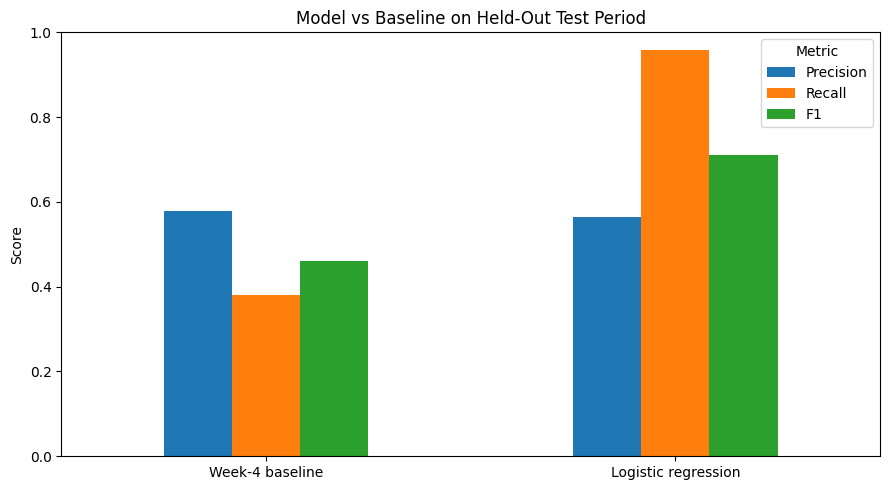

In [ ]:
# Model vs baseline comparison chart

import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Approach")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model vs Baseline on Held-Out Test Period")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Model vs baseline interpretation

Both approaches were evaluated on the same held-out April–May 2026 test period.

| Approach | Precision | Recall | F1 |
|---|---:|---:|---:|
| Week-4 baseline | 0.579 | 0.381 | 0.460 |
| Logistic regression | 0.565 | 0.958 | 0.711 |

The Week-4 baseline achieved precision of 0.579, recall of 0.381, and F1 of 0.460. The logistic regression model achieved precision of 0.565, recall of 0.958, and F1 of 0.711.

The two approaches therefore show different precision–recall trade-offs. The baseline identifies fewer of the observed decline cases, while the logistic regression model identifies a much larger share of them at the selected threshold. The model's precision is slightly lower than the baseline's precision, so model predictions should still be treated as a prioritization signal rather than a definitive decision.

These results describe predictive performance on the observed held-out period. They do not establish that refreshing content causes an improvement in Google Search performance.

## 5. Limitations



### What this work cannot claim

This analysis is designed as a prioritization system, not as a causal study of Google Search performance.

- The model predicts whether a content item's search impressions decline in the following month; it does not prove why the decline occurred.
- The analysis does not establish that refreshing a page will improve its future search performance.
- The dataset contains anonymized content and does not provide page-level context such as topic, content quality, backlinks, or specific search queries.
- The average-position feature is calculated as a simple monthly average and is not impression-weighted.
- GA4 metrics are unavailable for some observations and are handled as missing values by the modeling pipeline rather than assumed to be zero.
- The observed decline rate changes over time, including a substantially higher decline rate in the April–May 2026 test period than in training. This temporal distribution shift may affect test performance.
- The logistic regression model uses a limited set of observable search and engagement features; other models or additional features could produce different results.
- The threshold was selected on the validation period and then fixed for the held-out test evaluation. No claim is made that the selected threshold is universally optimal.
- The predictions should therefore be treated as a decision-support signal for human review rather than an automated content-refresh decision.

The study uses anonymized, public-safe data and does not expose client names, domains, URLs, private queries, or credentials.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Recommended action playbook

The model is intended to help prioritize content for human review. Recommendations are ordered by the type of evidence available from the current-period signals and the predicted decline risk.

#### 1. Review pages with high predicted decline risk and meaningful current search visibility

Prioritize pages where the model assigns a high probability of next-month impression decline and the page currently receives meaningful search impressions.

**Action:** Review the page for content freshness, search-intent alignment, outdated information, and opportunities to improve the content.

**Reason:** A predicted decline combined with existing search visibility provides a practical candidate for human review.

---

#### 2. Review pages with high predicted decline risk but validate the underlying signals

Pages with high predicted risk but lower current search volume should be reviewed selectively.

**Action:** Check whether the page has strategic importance, recent performance changes, or other business context that is not represented in the model.

**Reason:** The model uses a limited set of search and engagement signals and may miss important page-level context.

---

#### 3. Use position and impression opportunity as a supporting prioritization signal

The Week-4 baseline provides a simple rule-based view based on search position and impression volume.

**Action:** Use the baseline reason codes alongside the model prediction when deciding which pages require review.

**Reason:** The baseline provides an interpretable reference point and can help explain why a page entered the review queue.

---

#### 4. Send borderline predictions to human review rather than automating the decision

Predictions close to the decision threshold should not be treated as definitive.

**Action:** Review the page manually and consider additional information that is unavailable to the model.

**Reason:** The model is a prioritization tool, not a replacement for editorial or SEO judgment.

---

#### 5. Re-evaluate the model as new periods become available

The observed decline rate changed substantially between the training, validation, and test periods.

**Action:** Recalculate performance on future periods and monitor whether precision, recall, and F1 remain stable.

**Reason:** Changes in the underlying data distribution can affect model performance over time.

### Recommended decision flow

**Model risk signal → Current search visibility → Baseline reason code → Human review → Refresh/monitor decision**

The final refresh decision remains with the human reviewer. The model provides evidence for prioritization rather than a causal recommendation about whether a refresh will improve Google Search performance.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Embedded results artifacts

The deployed research paper should include the following artifacts from the capstone analysis:

#### 1. Dataset and label summary

A summary table showing:

- Total modeling observations: **1,331,441**
- Training observations: **406,006**
- Validation observations: **403,654**
- Test observations: **368,222**
- Training decline rate: **26.6%**
- Validation decline rate: **33.0%**
- Test decline rate: **56.0%**

This table provides context for the time-aware evaluation and the observed distribution shift.

#### 2. Decision-threshold analysis

The validation threshold table showing precision, recall, and F1 across thresholds from **0.30 to 0.80**.

The selected threshold is **0.40**, based on the highest validation F1 among the tested thresholds.

#### 3. Model vs baseline comparison

| Approach | Precision | Recall | F1 |
|---|---:|---:|---:|
| Week-4 baseline | 0.579 | 0.381 | 0.460 |
| Logistic regression | 0.565 | 0.958 | 0.711 |

#### 4. Model vs baseline chart

A bar chart comparing precision, recall, and F1 for the Week-4 baseline and logistic regression model on the same held-out April–May 2026 test period.

#### 5. Test-set confusion matrix

The logistic regression confusion matrix:

```text
[[ 10108 151913]
 [  8601 197600]]

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — Demo, social post, and employer-facing summary

### 5-minute demo outline

**1. Problem — 45 seconds**

Explain the decision problem: identify content pages that may experience a meaningful decline in future Google Search impressions so that they can be prioritized for human review.

**2. Data — 45 seconds**

Describe the anonymized FlyRank warehouse, the content-month unit of analysis, and the observable search and engagement features used by the model.

**3. Method — 60 seconds**

Explain the future-decline label, the time-aware train/validation/test split, the leakage controls, and the logistic regression pipeline with missing-value handling.

**4. Results — 90 seconds**

Show the validation threshold selection and the held-out April–May 2026 comparison.

- Week-4 baseline: Precision 0.579, Recall 0.381, F1 0.460
- Logistic regression: Precision 0.565, Recall 0.958, F1 0.711

Emphasize that these are predictive results on the observed test period and do not establish a causal effect of refreshing content.

**5. Decision support — 40 seconds**

Explain how the prediction can be used to prioritize pages for human review, alongside current search visibility and the interpretable Week-4 baseline signals.

**6. Limitations — 20 seconds**

Mention temporal distribution shift, limited feature coverage, missing GA4 observations, and the fact that predictions do not explain the cause of a decline.

**Closing message — 20 seconds**

The result is a repeatable prioritization workflow that combines observable search signals, a transparent baseline, and a time-aware ML evaluation.

---

### Social-post cut

Built a content-opportunity prediction workflow during the FlyRank ML Internship.

The project uses anonymized search and engagement signals to identify content pages that may experience a future decline in Google Search impressions. I compared a Week-4 rule-based baseline with a time-aware logistic regression model and evaluated both on the same held-out period.

The model achieved 0.565 precision, 0.958 recall, and 0.711 F1 on the observed April–May 2026 test period at a validation-selected threshold of 0.40.

The system is designed as decision support for prioritizing human review, not as a causal claim about content refreshes or Google Search rankings.

---

### Employer-facing summary

I built a time-aware machine learning workflow to prioritize content pages at risk of future search-impression decline using anonymized search and engagement data. The workflow compared an interpretable rule-based baseline with logistic regression and evaluated both on a held-out future period, with the model achieving an F1 score of 0.711 at the selected decision threshold. The project demonstrates practical skills in data preparation, leakage-aware feature design, time-based validation, model evaluation, and translating predictions into a human-review prioritization workflow.